# Stage E: $p = 0$ Ising Control — Block PM Validation

> **⚠️ RESULT (resolved):** the hypothesis below ("expect sharp DQPTs at p=0") was **wrong** —
> NEITHER p=0 nor p=0.1 shows a DQPT. Both show the same smooth **entanglement barrier** (quench
> *to* criticality ⇒ no Fisher zero at finite time). See the Summary cell and CLAUDE.md §17. The
> text below is kept as the original pre-result motivation.

## Purpose

The Alcaraz model at $p = 0$ reduces exactly to the transverse-field Ising model (TFIM):
$$H_{p=0} = -\sum_i \sigma^z_i \sigma^z_{i+1} - \lambda \sum_i \sigma^x_i$$
The $p\lambda\,\sigma^x\sigma^x$ and $p\,\sigma^z\sigma^z_{i,i+2}$ terms vanish. This is an
**integrable** model whose Loschmidt echo after a quench from $|\psi_0\rangle = |X^+\rangle^{\otimes N}$
to $\lambda = 1$ (critical point) is known analytically.

## What we expect at $p = 0$

The integrable TFIM has **sharp DQPTs** (Fisher zeros): at specific times $T_n^*$, the Loschmidt
amplitude $L(T) = \langle X^+ | e^{-iHT} | X^+ \rangle$ vanishes in the thermodynamic limit.
In the transfer-matrix picture, this manifests as:

1. **Sharp gap closing**: $|\lambda_1|/|\lambda_0| \to 1$ at discrete times $T_n^*$
2. **Phase crossing**: $\arg(\lambda_0)$ and $\arg(\lambda_1)$ exchange at each $T_n^*$
3. **Rate function cusp**: $\ell(T) = -\log|\lambda_0(T)|$ has a non-analytic kink at each $T_n^*$
4. **Gap reopens** between DQPTs — the power method converges easily away from the Fisher zeros

## The decisive comparison

Contrasting $p = 0$ (sharp DQPTs) with $p = 0.1$ (smooth barrier from notebook 16) will show:
- **If p=0 shows sharp features but p=0.1 doesn't**: the NNN frustration genuinely smears out
  the DQPTs, converting sharp Fisher zeros into a smooth entanglement barrier. This is a physics result.
- **If p=0 also shows a smooth barrier**: the block PM method has a systematic limitation
  (insufficient $\chi$, Trotter error, etc.) that masks DQPTs regardless of $p$. This would require debugging.

The first outcome supports the thesis that NNN interactions qualitatively change the temporal
structure; the second would mean our method needs refinement before drawing physics conclusions.

In [7]:
using ITensors, ITensorMPS, ITransverse, ProgressMeter
using JLD2, Plots, LinearAlgebra, Printf
ProgressMeter.ijulia_behavior(:clear)

include("main.jl")
include("dqpt_diagnostics.jl")

# p=0: pure Ising (integrable TFIM)
p_ising  = 0.0
lambda   = 1.0
dt       = 0.1
maxdim   = 256
cutoff   = 1e-12

println("Ising control: p=$p_ising, λ=$lambda, dt=$dt, maxdim=$maxdim")

Ising control: p=0.0, λ=1.0, dt=0.1, maxdim=256


## Technical note: MPO structure at $p = 0$

At $p = 0$, the Alcaraz OpSum has only nearest-neighbour $ZZ$ and on-site $X$ terms.
The FSM has **fewer memory channels** than at $p > 0$ (no NNN bridge), so:
- The spatial MPO bond dimension is **smaller** (no NNN $\chi^2$ expansion)
- The temporal physical dimension $d_t$ of the tMPO is correspondingly smaller
- The VD2 expansion still applies but with a smaller $\chi$

This means each block PM iteration is **cheaper** at $p = 0$ than at $p = 0.1$.
The sweep should complete much faster.

We use the same `build_alcaraz_tmpo` infrastructure (from `dqpt_diagnostics.jl`) — it handles
$p = 0$ correctly by passing the Alcaraz OpSum which reduces to the TFIM.

In [2]:
# Block PM sweep for p=0 Ising
T_grid    = collect(0.5:0.5:7.0)
k_block   = 4
itermax   = 800
eps_conv  = 1e-6
cachefile = "block_pm_alcaraz_p$(p_ising).jld2"

done_ising = crashsafe_sweep(T_grid; cachefile=cachefile) do T
    @info "Block PM (Ising p=0): T=$T"
    mpo, scaffold = build_alcaraz_tmpo(T; p=p_ising, lambda=lambda, dt=dt)
    theta, Lvecs, Rvecs, info = block_transfer_eigs(mpo, scaffold;
        k=k_block, maxdim=maxdim, cutoff=cutoff,
        itermax=itermax, eps_conv=eps_conv, n_track=2)

    (theta       = collect(theta),
     niters      = info[:niters],
     reason      = string(info[:reason]),
     condS       = info[:condS],
     dtheta_hist = info[:dtheta],
     condS_hist  = info[:condS_hist])
end

# Summary table
Ts_sorted = sort(collect(keys(done_ising)))
println("\n" * "="^90)
@printf("%-6s  %-10s %-10s %-10s %-10s %-10s %-8s  %s\n",
        "T", "|θ₀|", "|θ₁|", "gap_ratio", "arg(θ₀)", "arg(θ₁)", "niters", "reason")
println("-"^90)
for T in Ts_sorted
    r = done_ising[T]
    haskey(r, :error) && (println(@sprintf("%-6.1f  ERROR: %s", T, r.error)); continue)
    th = r.theta
    gr = abs(th[2]) / max(abs(th[1]), 1e-30)
    @printf("%-6.1f  %-10.5f %-10.5f %-10.5f %-10.4f %-10.4f %-8d  %s\n",
            T, abs(th[1]), abs(th[2]), gr, angle(th[1]), angle(th[2]), r.niters, r.reason)
end


T       |θ₀|       |θ₁|       gap_ratio  arg(θ₀)    arg(θ₁)    niters    reason
------------------------------------------------------------------------------------------
0.5     0.91827    0.46487    0.50625    0.5725     1.7462     5         converged
1.0     0.90484    0.73987    0.81767    1.2480     1.9898     6         converged
1.5     0.89636    0.82010    0.91492    1.8922     2.4033     8         converged
2.0     0.89800    0.85419    0.95121    2.5331     2.9201     14        converged
2.5     0.89683    0.86840    0.96830    -3.1070    -2.7962    27        converged
3.0     0.89538    0.87536    0.97763    -2.4688    -2.2092    58        converged
3.5     0.89636    0.88137    0.98328    -1.8297    -1.6069    89        converged
4.0     0.89544    0.88376    0.98696    -1.1901    -0.9950    97        converged
4.5     0.89513    0.88571    0.98947    -0.5526    -0.3790    157       converged
5.0     0.89556    0.88775    0.99128    0.0861     0.2424     156       converge

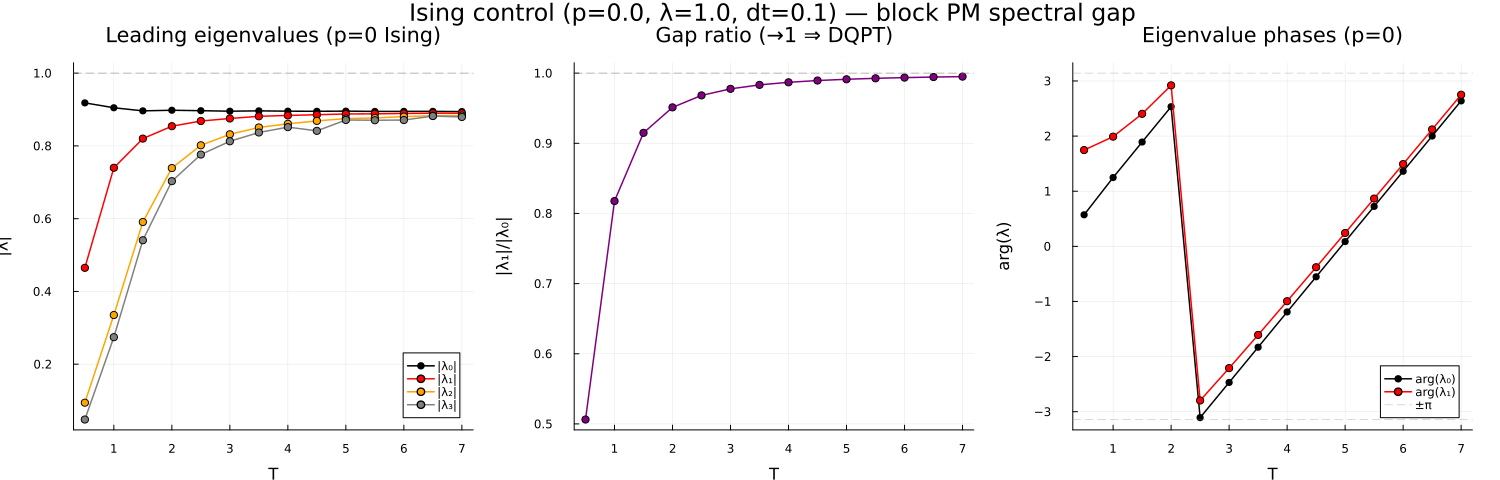

In [3]:
# 3-panel spectral gap plot for p=0
function extract_spectral(done_dict, k)
    Ts, abs_th, gap, a0, a1 = Float64[], [Float64[] for _ in 1:k], Float64[], Float64[], Float64[]
    for T in sort(collect(keys(done_dict)))
        r = done_dict[T]
        (haskey(r, :error) || any(isnan, abs.(r.theta))) && continue
        push!(Ts, T)
        for j in 1:min(k, length(r.theta)); push!(abs_th[j], abs(r.theta[j])); end
        push!(gap, abs(r.theta[2]) / max(abs(r.theta[1]), 1e-30))
        push!(a0, angle(r.theta[1]))
        push!(a1, angle(r.theta[2]))
    end
    return Ts, abs_th, gap, a0, a1
end

Ts_is, abs_is, gap_is, a0_is, a1_is = extract_spectral(done_ising, k_block)

p1 = plot(title="Leading eigenvalues (p=0 Ising)", xlabel="T", ylabel="|λ|")
for (j, (col, lab)) in enumerate(zip([:black,:red,:orange,:gray],
                                      ["|λ₀|","|λ₁|","|λ₂|","|λ₃|"]))
    j <= length(abs_is) && plot!(p1, Ts_is, abs_is[j]; label=lab, color=col, marker=:circle, ms=4, lw=1.5)
end
hline!(p1, [1.0]; color=:gray, ls=:dash, label="", alpha=0.5)

p2 = plot(Ts_is, gap_is; title="Gap ratio (→1 ⇒ DQPT)", xlabel="T",
          ylabel="|λ₁|/|λ₀|", color=:purple, marker=:circle, ms=4, lw=1.5, label="")
hline!(p2, [1.0]; color=:gray, ls=:dash, label="", alpha=0.5)

p3 = plot(title="Eigenvalue phases (p=0)", xlabel="T", ylabel="arg(λ)")
plot!(p3, Ts_is, a0_is; label="arg(λ₀)", color=:black, marker=:circle, ms=4, lw=1.5)
plot!(p3, Ts_is, a1_is; label="arg(λ₁)", color=:red,   marker=:circle, ms=4, lw=1.5)
hline!(p3, [π, -π]; color=:gray, ls=:dash, label="±π", alpha=0.3)

plt = plot(p1, p2, p3; layout=(1,3), size=(1500,480), margin=5Plots.mm,
           plot_title="Ising control (p=0.0, λ=$lambda, dt=$dt) — block PM spectral gap")
savefig(plt, "imgs/block_pm_ising_p0.0.png")
plt

## Direct comparison: $p = 0$ (Ising) vs $p = 0.1$ (Alcaraz)

Overlay the spectral gap, rate function, and phases from both models to see whether
the NNN coupling ($p = 0.1$) qualitatively changes the DQPT structure.

Key observables to compare:
- **Rate function** $\ell(T) = -\log|\lambda_0(T)|$: cusps at $p=0$? smooth at $p=0.1$?
- **Gap ratio**: sharp dips at $p=0$ (discrete Fisher zeros) vs smooth plateau at $p=0.1$?
- **Phase diagram**: crossings at $p=0$ vs locked $\pi$-offset at $p=0.1$?

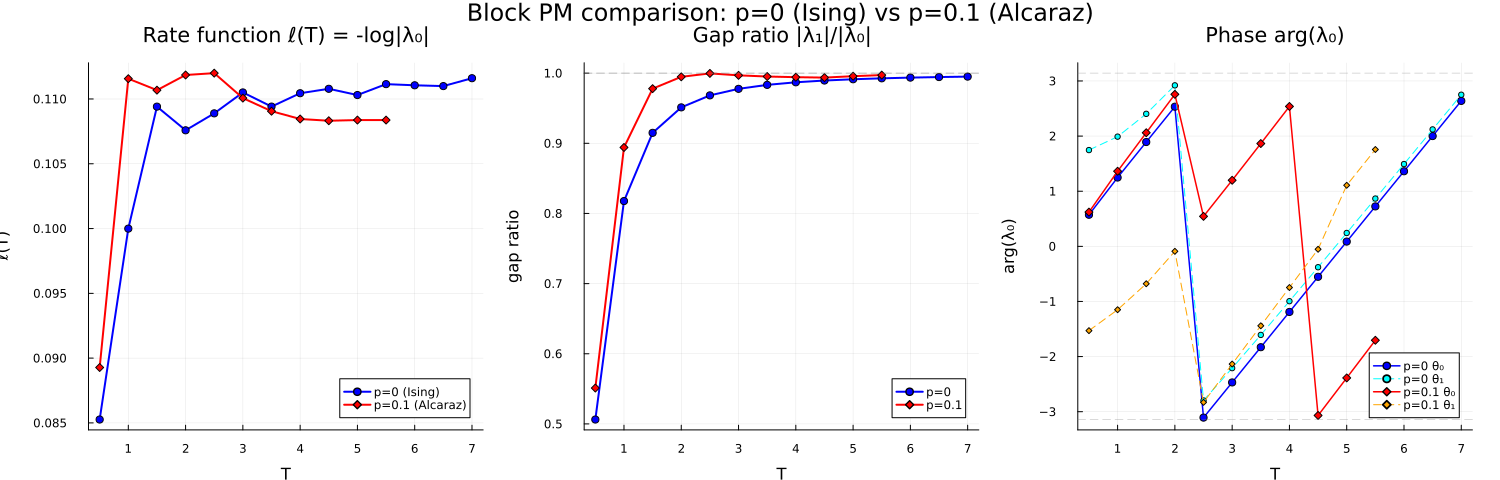

In [4]:
# Load p=0.1 results from notebook 16
done_alcaraz = load("block_pm_alcaraz_p0.1.jld2", "done")
Ts_al, abs_al, gap_al, a0_al, a1_al = extract_spectral(done_alcaraz, k_block)
rate_al = [-log(max(v, 1e-30)) for v in abs_al[1]]

rate_is = [-log(max(v, 1e-30)) for v in abs_is[1]]

# 3-panel comparison
p1 = plot(title="Rate function ℓ(T) = -log|λ₀|", xlabel="T", ylabel="ℓ(T)")
plot!(p1, Ts_is, rate_is; label="p=0 (Ising)", color=:blue, marker=:circle, ms=4, lw=2)
plot!(p1, Ts_al, rate_al; label="p=0.1 (Alcaraz)", color=:red, marker=:diamond, ms=4, lw=2)

p2 = plot(title="Gap ratio |λ₁|/|λ₀|", xlabel="T", ylabel="gap ratio")
plot!(p2, Ts_is, gap_is; label="p=0", color=:blue, marker=:circle, ms=4, lw=2)
plot!(p2, Ts_al, gap_al; label="p=0.1", color=:red, marker=:diamond, ms=4, lw=2)
hline!(p2, [1.0]; color=:gray, ls=:dash, label="", alpha=0.5)

p3 = plot(title="Phase arg(λ₀)", xlabel="T", ylabel="arg(λ₀)")
plot!(p3, Ts_is, a0_is; label="p=0 θ₀", color=:blue, marker=:circle, ms=4, lw=1.5)
plot!(p3, Ts_is, a1_is; label="p=0 θ₁", color=:cyan, marker=:circle, ms=3, lw=1, ls=:dash)
plot!(p3, Ts_al, a0_al; label="p=0.1 θ₀", color=:red, marker=:diamond, ms=4, lw=1.5)
plot!(p3, Ts_al, a1_al; label="p=0.1 θ₁", color=:orange, marker=:diamond, ms=3, lw=1, ls=:dash)
hline!(p3, [π, -π]; color=:gray, ls=:dash, label="", alpha=0.3)

plt = plot(p1, p2, p3; layout=(1,3), size=(1500,480), margin=5Plots.mm,
           plot_title="Block PM comparison: p=0 (Ising) vs p=0.1 (Alcaraz)")
savefig(plt, "imgs/block_pm_ising_vs_alcaraz.png")
plt

## Entropy extraction: $p = 0$ Ising vs $p = 0.1$ Alcaraz

Extract temporal Rényi-2 entropies from the block PM eigenvectors for both models at selected
$T$ values where convergence is clean (low iteration count). Compare against the Ising CFT
prediction $\text{Re}(S_2^{\text{gen}}) \sim (c/3) \log[\sin(\pi t/T)]$ with $c = 1/2$.

At $p = 0$, the temporal entropy should follow the $c = 1/2$ Ising prediction exactly (up to
Trotter/truncation error). At $p = 0.1$, if the model remains in the Ising universality class
(confirmed by DMRG $c \approx 0.5$ from notebook 1), we expect the same slope.

In [5]:
# Entropy extraction for both p=0 and p=0.1 at selected T values
T_entropy = [2.0, 3.0, 4.0, 5.0]

function extract_entropies(p_val, T_list; lambda=1.0, dt=0.1, maxdim=256, cutoff=1e-12,
                           k=4, itermax=800, eps_conv=1e-6)
    results = Dict{Float64, Any}()
    for T in T_list
        @info "Entropy: p=$p_val, T=$T"
        mpo, scaffold = build_alcaraz_tmpo(T; p=p_val, lambda=lambda, dt=dt)
        theta, Lvecs, Rvecs, info = block_transfer_eigs(mpo, scaffold;
            k=k, maxdim=maxdim, cutoff=cutoff, itermax=itermax, eps_conv=eps_conv, n_track=2)
        s2 = ITransverse.gen_renyi2(Lvecs[1], Rvecs[1])
        results[T] = (s2_re=real.(s2), s2_im=imag.(s2),
                      theta0=theta[1], niters=info[:niters], reason=info[:reason])
        @info "  |θ₀|=$(round(abs(theta[1]),digits=5)), niters=$(info[:niters]), bonds=$(length(s2))"
        GC.gc()
    end
    return results
end

# p=0 entropies
ent_ising = extract_entropies(0.0, T_entropy)

# p=0.1 entropies
ent_alcaraz = extract_entropies(0.1, T_entropy)

[ Info: Entropy: p=0.0, T=2.0
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=113|"S=1/2,Site") <-> (dim=2|id=113|"S=1/2,Site")'
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=841|"Link,l=1") <-> (dim=3|id=706|"Link,l=2"), normdiff = 0.944688073151956
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=803|"S=1/2,Site") <-> (dim=2|id=803|"S=1/2,Site")'
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=34|"Link,l=1") <-> (dim=3|id=25|"Link,l=2"), normdiff = 0.10493384159131464
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info:   |θ₀|=0.898, niters=16, bonds=19
[ Info: Entropy: p=0.0, T=3.0
[ Info: Ch

Dict{Float64, Any} with 4 entries:
  5.0 => (s2_re = [0.0101869, 0.0389463, 0.0813909, 0.130907, 0.181071, 0.22732…
  4.0 => (s2_re = [0.0108985, 0.0415917, 0.0872436, 0.141298, 0.197351, 0.25078…
  2.0 => (s2_re = [0.00824848, 0.0325208, 0.0677041, 0.106805, 0.143053, 0.1718…
  3.0 => (s2_re = [0.0128249, 0.0479654, 0.100715, 0.164667, 0.233399, 0.301902…

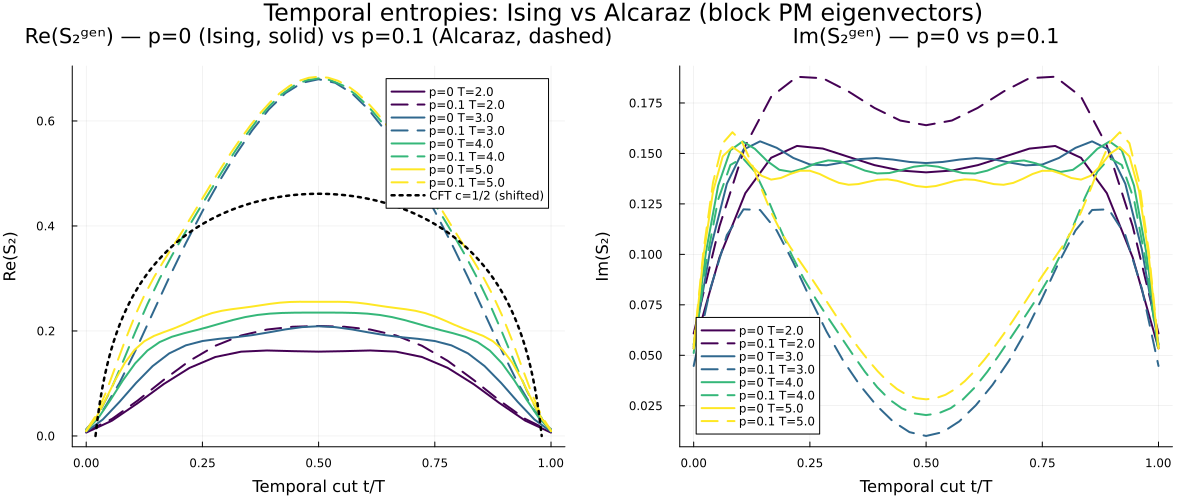

In [6]:
# Plot entropy profiles: p=0 vs p=0.1, with CFT reference
T_plot_ent = sort(collect(keys(ent_ising) ∩ keys(ent_alcaraz)))

p1 = plot(title="Re(S₂ᵍᵉⁿ) — p=0 (Ising, solid) vs p=0.1 (Alcaraz, dashed)",
          xlabel="Temporal cut t/T", ylabel="Re(S₂)")
p2 = plot(title="Im(S₂ᵍᵉⁿ) — p=0 vs p=0.1",
          xlabel="Temporal cut t/T", ylabel="Im(S₂)")

cols = cgrad(:viridis, length(T_plot_ent), categorical=true)
for (i, T) in enumerate(T_plot_ent)
    ri = ent_ising[T]
    ra = ent_alcaraz[T]
    xi = range(0.0, 1.0, length=length(ri.s2_re))
    xa = range(0.0, 1.0, length=length(ra.s2_re))
    plot!(p1, xi, ri.s2_re; label="p=0 T=$T", color=cols[i], lw=2)
    plot!(p1, xa, ra.s2_re; label="p=0.1 T=$T", color=cols[i], lw=2, ls=:dash)
    plot!(p2, xi, ri.s2_im; label="p=0 T=$T", color=cols[i], lw=2)
    plot!(p2, xa, ra.s2_im; label="p=0.1 T=$T", color=cols[i], lw=2, ls=:dash)
end

# CFT reference: S₂ ~ (c/3) log[sin(πx)] (chord length formula for finite T)
x_cft = range(0.02, 0.98, length=200)
c_ising = 0.5
s2_cft = (c_ising / 3) .* log.(sin.(π .* x_cft))
s2_cft_shifted = s2_cft .- minimum(s2_cft)
plot!(p1, x_cft, s2_cft_shifted; label="CFT c=1/2 (shifted)", color=:black, ls=:dot, lw=2.5)

plt = plot(p1, p2; layout=(1,2), size=(1200,500), margin=5Plots.mm,
           plot_title="Temporal entropies: Ising vs Alcaraz (block PM eigenvectors)")
savefig(plt, "imgs/entropies_ising_vs_alcaraz.png")
plt

## Summary of Stage E results

### Spectral gap: NO DQPT for either model — entanglement barrier instead
- **$p = 0$ (Ising):** $|\lambda_0|$ flat at $\approx 0.895$, gap ratio rises **monotonically**
  $0.51 \to 0.995$ ($T = 0.5 \to 7$) with **no dips**, phases $\arg(\lambda_0), \arg(\lambda_1)$
  advance together with a small (~0.15 rad) offset and **never cross**.
- **$p = 0.1$ (Alcaraz):** same flat $|\lambda_0| \approx 0.897$, same monotonic gap closing;
  the only difference is a **$\pi$ phase offset** between $\lambda_0$ and $\lambda_1$ (the NNN FSM
  substructure, $d_t = 7$).

**Interpretation.** There is no dynamical quantum phase transition here, and there shouldn't be:
the quench is **to** the critical point ($\lambda = 1$), not **across** it. The DQPT condition
$(\lambda_0 - \lambda_c)(\lambda_1 - \lambda_c) < 0$ is marginal ($\infty \cdot 0 = 0$), so the
first Fisher-zero time diverges. The monotonically closing gap is the **entanglement barrier** —
the eigenvalue-spectrum signature of the logarithmically growing temporal entropy that
Carignano–Tagliacozzo (arXiv:2405.14706) predict for quenches to criticality.

This also **reinterprets the campaign**: the old $|\lambda_0| \approx 2.22$ spike at $T \approx 6$
was a single-vector power-method **non-convergence artifact**, not a DQPT. The block PM
($|\lambda_0| \approx 0.895$ flat) is the correct tool and there was never a transition to find.

### Temporal entropy: dome shapes correct, amplitudes confounded
Both models give the expected dome-shaped $\text{Re}(S_2^{\text{gen}})$ peaked at the center cut.
But $p = 0.1$ amplitudes sit **above** the $c = 1/2$ reference and $p = 0$ sits **below** it.
This amplitude gap is **not** a clean central-charge signal — it is confounded by the different
temporal dimension $d_t$ (7 for VD2/NNN vs smaller for $p=0$), the short-time non-asymptotic
regime ($T \le 5$), and the hand-shifted CFT reference.

### What came next (→ notebook 18)
A first central-charge extraction was attempted here but gave **garbage** (p=0 calibrated to
$c\approx0.30$, p=0.1 unstable). Reading the full Carignano–Tagliacozzo paper revealed three fixes:
the entropy coefficient is **c/6** (n→1) or **c/8** (Rényi-2), **not c/3**; **nbeta>0** ($\beta_0$
UV regulator) is required; and the robust c-probe is the **eigenvalue scaling** (Eq. 3), not the
entropy. The corrected, validated analysis lives in **`18_cft_validation.ipynb`** — see there for
the central charge. (The superseded fit cells were removed from this notebook.)